In [1]:
%matplotlib widget

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [2]:
columns = [
    "shoe_hand_idx",
    "dealer_hand",
    "player_hand_0",
    "player_hand_1",
    "total_bet",
    "net_value",
    "true_count",
    "remaining_cards",
    "datetime"
]

In [3]:
start_date = datetime(2025, 12, 25)

In [4]:
prefix = "tw_play_"

result_tables = list(sorted(glob.glob(f"../logs/{prefix}*.csv")))

result_datetimes = [
    datetime.strptime(os.path.basename(t), f"{prefix}%Y_%m_%d_%H_%M_%S.csv") 
    for t in result_tables
]
result_tables = [
    t for t, dt in zip(result_tables, result_datetimes)
    if dt >= start_date
]


In [5]:
result_tables

['../logs/tw_play_2025_12_25_23_21_25.csv',
 '../logs/tw_play_2025_12_25_23_33_14.csv']

In [6]:
table = pd.read_csv(result_tables[0])

In [7]:
table["net_value"]

0   -250
1   -250
2   -250
3    250
4   -500
5    750
6   -250
7   -250
Name: net_value, dtype: int64

In [8]:
tables = [pd.read_csv(t) for t in result_tables]
tables = [t for t in tables if len(t) > 0]

In [9]:
main_table = pd.concat(tables)

In [10]:
cum_value = np.cumsum(main_table["net_value"].values)
cum_value = np.r_[0, cum_value]

In [11]:
# ev_per_hand_units = 0.008
# sd_per_hand_units = 3.5
ev_per_hand_units = 42.312833884831015 / 1000
sd_per_hand_units = 7167.133282047346 / 1000
unit = 250

mu = ev_per_hand_units * unit
sigma = sd_per_hand_units * unit
hand_idx = np.arange(len(cum_value))
ev = mu * hand_idx
sd = np.sqrt(hand_idx) * sigma

KeyError: 'true_count'

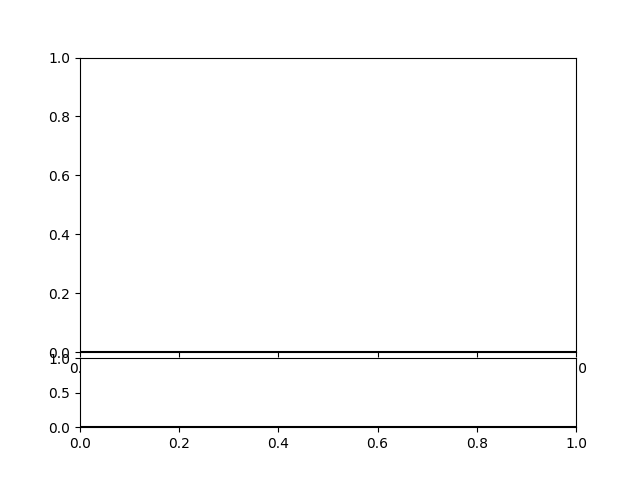

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure()
gs = gridspec.GridSpec(10, 1, figure=fig)


ax = fig.add_subplot(gs[:-2, :])
ax2 = fig.add_subplot(gs[-2:, :])
ax.axhline(0, color="black")
ax2.axhline(0, color="black")

main_table["ev"]

ax.plot(cum_value, label="performance")
ax.plot(ev, color="gray", label="ev")
ax.plot(ev + sd, color="grey", ls="--", label="1σ")
ax.plot(ev - sd, color="gray", ls="--")

ax2.plot(main_table["true_count"].values, color="red")

ax.legend()